Step 1: Import the libraries

In [1]:
import matplotlib.pyplot as plt

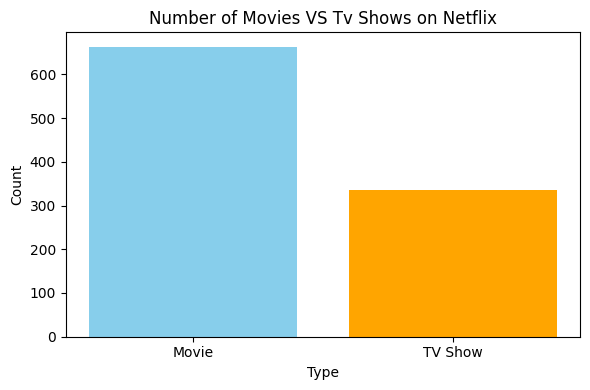

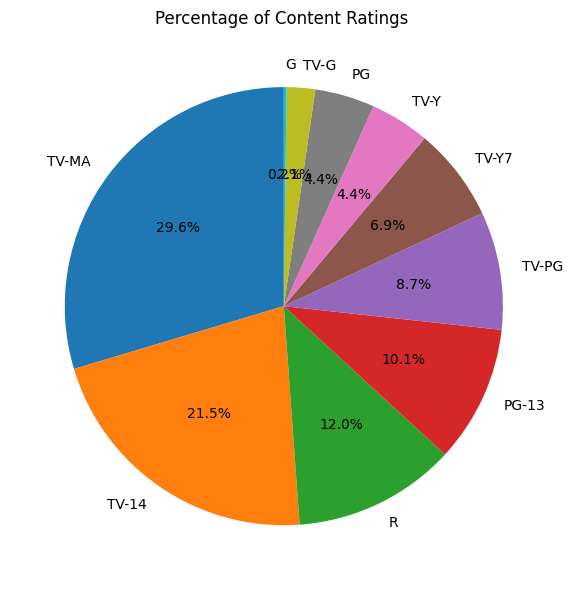

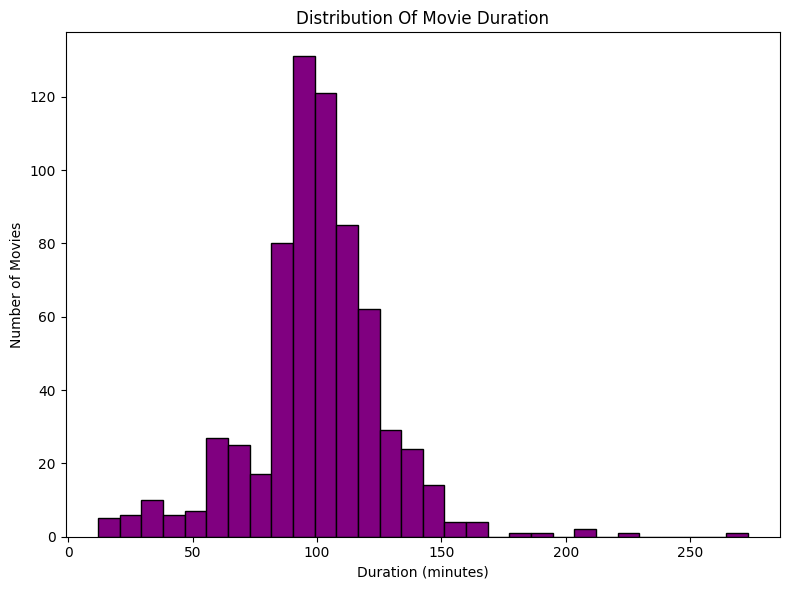

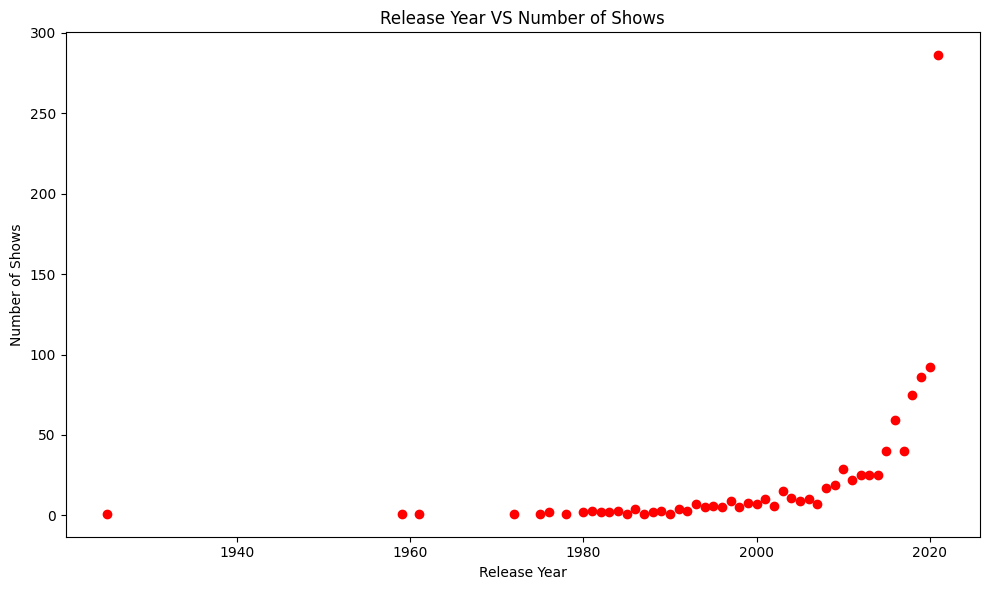

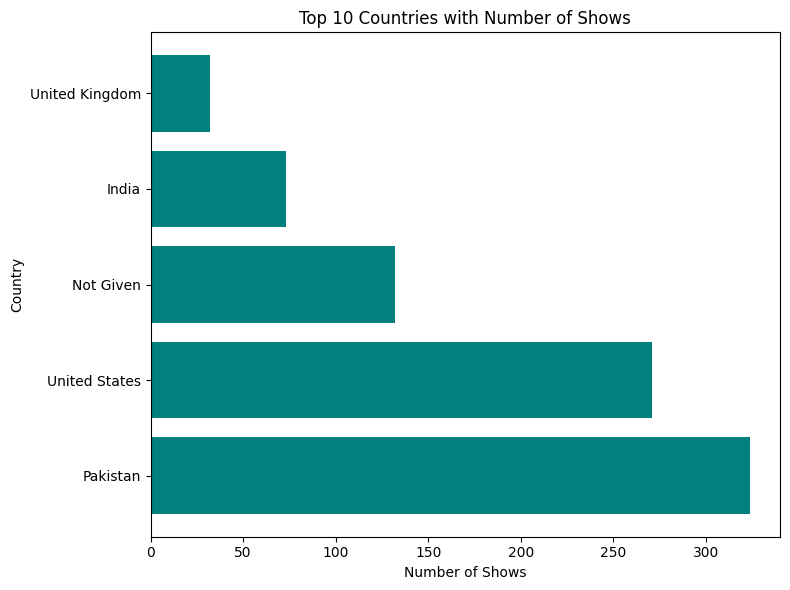

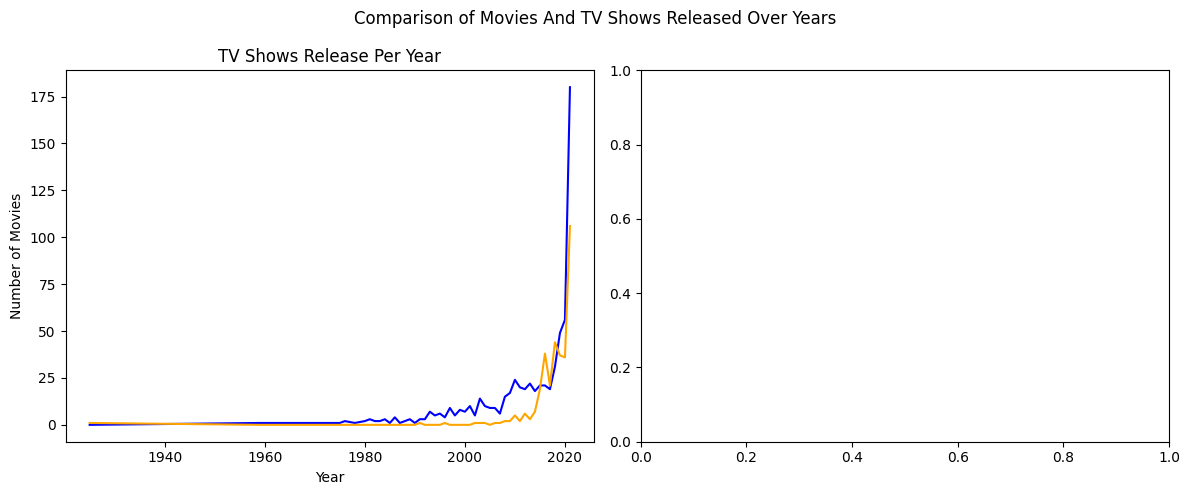

In [22]:
import pandas as pd

# Load the data 
df= pd.read_csv("netflix1.csv", encoding='latin1')
#print(df.head())

# Clean Data
df=df.dropna(subset=['type','title','release_year','rating','country','duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue','orange'])
plt.title('Number of Movies VS Tv Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

# Counting_ratings
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts,labels=rating_counts.index, autopct='%1.1f%%',startangle=90)
plt.title('Percentage of Content Ratings ')
plt.tight_layout()
plt.savefig('content_ratings_pie.png')
plt.show()

#Movies Distributed using histogram
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_int']=movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'],bins=30,color='purple',edgecolor='black')
plt.title('Distribution Of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()

# Release Year VS Number of shows using scatter plot
release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title('Release Year VS Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.savefig('Release_year_scatter.png')
plt.show()

# Top 10 countries with the highest no. of shows using horizontal bar chart
country_counts=df['country'].value_counts().head()
plt.figure(figsize=(8,6))
plt.barh(country_counts.index,country_counts.values,color='teal')
plt.title('Top 10 Countries with Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_10_country.png')
plt.show()

# Movies Vs Tv Shows by year by grouping the data
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,5))

#First subplot:movies
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')
#Second subplot:Tv_shows
ax[0].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[0].set_title('TV Shows Release Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

fig.suptitle('Comparison of Movies And TV Shows Released Over Years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparsion.png')
plt.show()
